In [ ]:
The objective of this project is to analyze and predict crude oil prices using machine learning techniques by integrating multiple real-world datasets. Oil prices are highly volatile and influenced by various factors such as geopolitical events, economic conditions, sanctions, and supply-demand dynamics.

To address this complexity, this project adopts a data-driven approach by combining historical oil price data with external influencing variables like risk indicators, geopolitical events, sanctions, and export data. By leveraging these datasets, the model aims to capture both temporal patterns and external impacts to improve prediction accuracy.

In [ ]:
!pip install pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
oil = pd.read_csv('/oil_prices_daily.csv')
risk = pd.read_csv('/risk_indicators.csv')
events = pd.read_csv('/geopolitical_events.csv')
sanctions = pd.read_csv('/sanctions_timeline.csv')
exports = pd.read_csv('/iran_oil_exports.csv')

In [ ]:
print(oil.head())
print(oil.info())
print(oil.describe())

         date  brent_usd  wti_usd  dubai_usd  brent_wti_spread  \
0  1990-01-02      20.00    18.32      19.44              1.68   
1  1990-01-03      20.09    13.66      19.23              6.43   
2  1990-01-04      19.78    17.66      18.75              2.12   
3  1990-01-05      20.01    14.89      17.94              5.12   
4  1990-01-08      20.29    17.28      18.58              3.01   

   brent_daily_return_pct  brent_30d_vol  hormuz_risk_premium_pct  \
0                  0.0000            0.0                     0.38   
1                  0.4621            0.0                     1.06   
2                 -1.5550            0.0                     1.49   
3                  1.1307            0.0                     0.96   
4                  1.4158            0.0                     0.43   

   is_geopolitical_event event_type event_description  opec_production_mbd  \
0                      0        NaN               NaN                31.38   
1                      0        

In [ ]:
The dataset used in this project is a multivariate time-series dataset constructed by merging multiple data sources based on time. It includes daily oil prices along with several external variables that influence price fluctuations.

Each dataset contributes a different perspective:

The oil prices dataset provides the target variable (Brent crude price).
Risk indicators represent economic and market uncertainty.
Geopolitical events capture sudden global disruptions.
Sanctions data reflects long-term political pressure.
Export data represents oil supply levels.

Together, these datasets form a comprehensive framework that enables the model to learn complex relationships between oil prices and real-world influencing factors.

In [ ]:
oil['date'] = pd.to_datetime(oil['date'])
risk['date'] = pd.to_datetime(risk['date'])
events['date'] = pd.to_datetime(events['date'])
sanctions['date'] = pd.to_datetime(sanctions['date'])

In [ ]:
# Merge daily datasets
df = oil.merge(risk, on='date', how='left')
df = df.merge(events, on='date', how='left')
df = df.merge(sanctions[['date','cumulative_pressure_score']], on='date', how='left')

# Merge yearly exports (based on year)
df['year'] = df['date'].dt.year
exports['year'] = exports['year']

df = df.merge(exports, on='year', how='left')

In [ ]:
df.fillna(method='ffill', inplace=True)
df.fillna(0, inplace=True)

/tmp/ipykernel_10901/699617349.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
# Lag features
df['lag_1'] = df['brent_usd'].shift(1)
df['lag_3'] = df['brent_usd'].shift(3)
df['lag_7'] = df['brent_usd'].shift(7)

# Rolling mean
df['rolling_mean_7'] = df['brent_usd'].rolling(7).mean()

# Date features
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df.dropna(inplace=True)

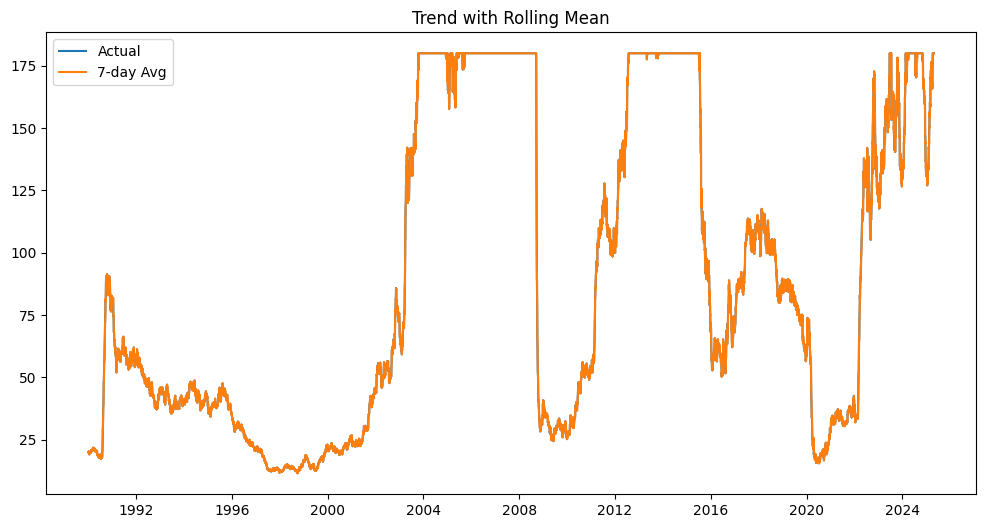

In [ ]:
df['rolling_mean_7'] = df['brent_usd'].rolling(7).mean()

plt.figure(figsize=(12,6))
plt.plot(df['date'], df['brent_usd'], label='Actual')
plt.plot(df['date'], df['rolling_mean_7'], label='7-day Avg')
plt.legend()
plt.title("Trend with Rolling Mean")
plt.show()

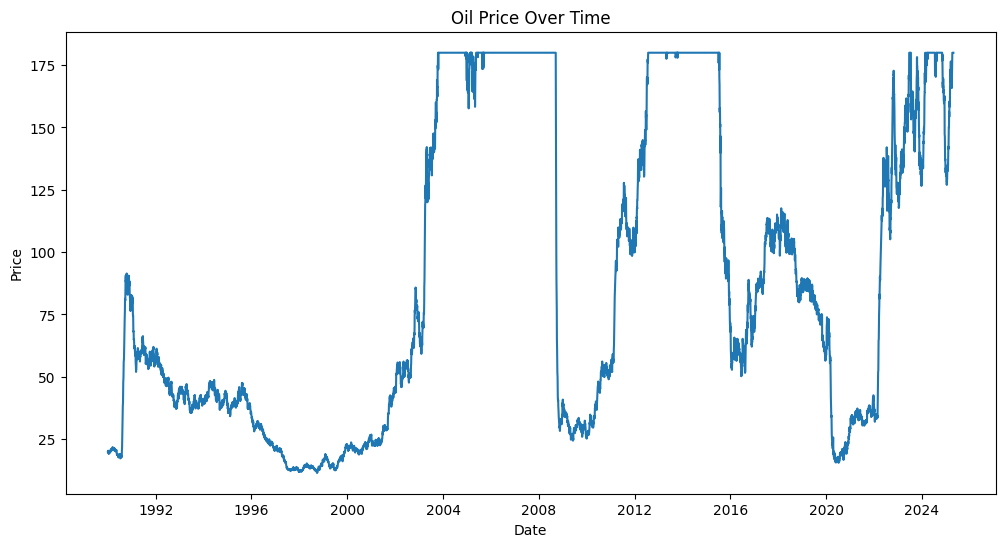

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['brent_usd'])
plt.title("Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
X = df.drop(['date','brent_usd'], axis=1)
y = df['brent_usd']

# Identify categorical columns
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [ ]:
preds = model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("✅ RMSE:", rmse)

✅ RMSE: 0.4673291510518508


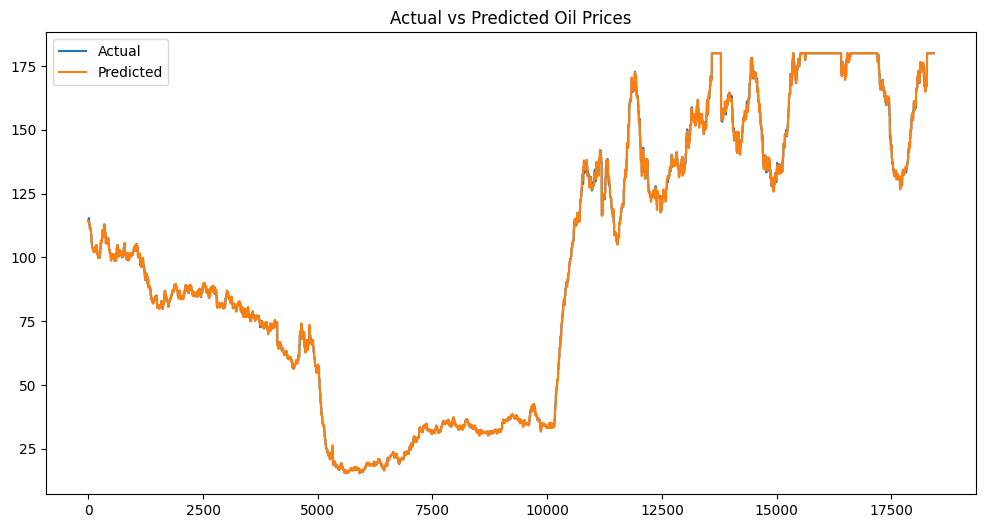

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Oil Prices")
plt.show()

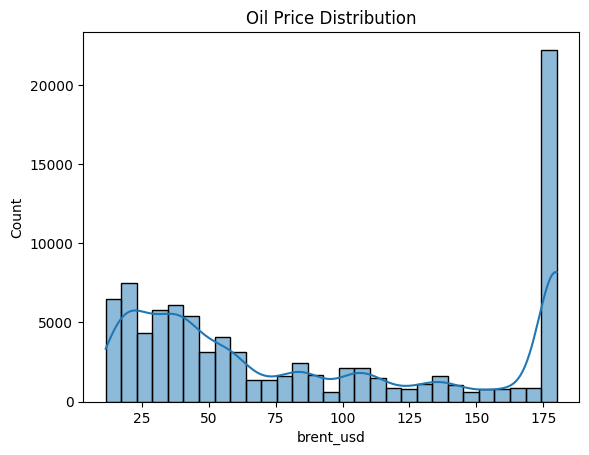

In [ ]:
sns.histplot(df['brent_usd'], kde=True)
plt.title("Oil Price Distribution")
plt.show()

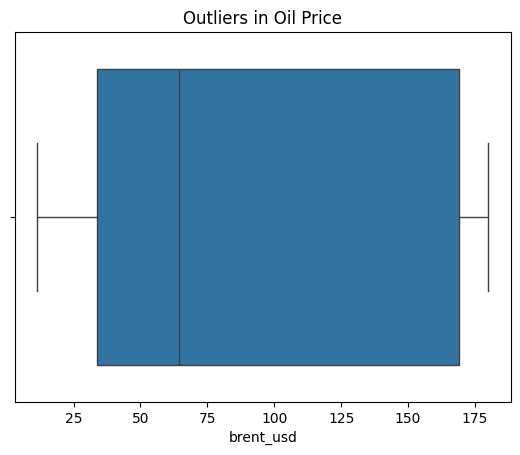

In [ ]:
sns.boxplot(x=df['brent_usd'])
plt.title("Outliers in Oil Price")
plt.show()

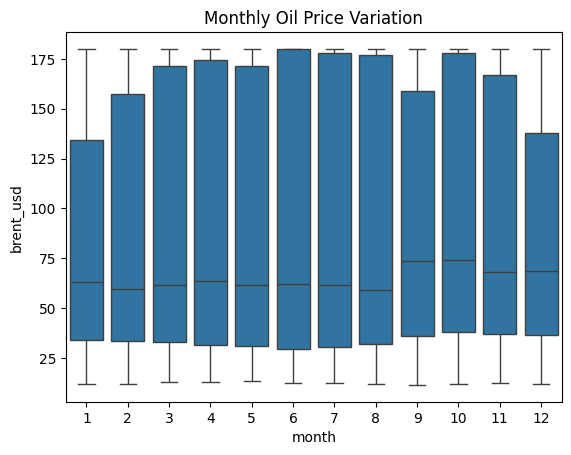

In [ ]:
df['month'] = df['date'].dt.month

sns.boxplot(x=df['month'], y=df['brent_usd'])
plt.title("Monthly Oil Price Variation")
plt.show()